**Adani Enterprises**



Adani Enterprises Limited, the flagship company of the Adani Group has been driven by the philosophy of incubating stellar infrastructural asset catering to underserved sectors of India. It’s diversified portfolio is broadly split into energy & utilities, transport & logistics and emerging businesses.

Since the Company’s listing in 1994, it has maximised value for stakeholders, while contributing to nation building. Adani Enterprises Limited is presently focused on businesses related to airports, roads, water management, data centers, solar manufacturing, defence and aerospace, edible oils and foods, mining, integrated resource solutions and integrated agri products.





**Required packages**

In [ ]:
# Install necessary packages
install.packages("readr")
install.packages("forecast")
install.packages("ggplot2")
install.packages("googlesheets4")
library(googlesheets4)

library(readr)
library(forecast)
library(ggplot2)

install.packages("stats")
library(stats)
install.packages("Metrics")
library(Metrics)
install.packages("zoo")
library(zoo)
install.packages("quantmod")
library(quantmod)
install.packages("xts")
library(xts)
install.packages("seastests")
library(seastests)


install.packages("dplyr")
library(dplyr)
install.packages("mFilter")
library(mFilter)
install.packages("tseries")
library(tseries)
install.packages("gridExtra")
library(gridExtra)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘quantmod’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘tseries’, ‘urca’, ‘zoo’, ‘RcppArmadillo’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Warning message:
“package ‘stats’ is a base package, and should not be updated”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘Metrics’


The following object is masked from ‘package:forecast’:

    accuracy


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is u

**Load data:**

In [ ]:
sheet_url <- "https://docs.google.com/spreadsheets/d/1bA0vfvFBUK8Q3U9ICUWIAUfmJmOIzVvVTBd9e2zrrNc/edit?usp=sharing"
adani_prices <- read_sheet(sheet_url)
adani_prices$Date_N <- as.Date(adani_prices$Date_N, format="%Y-%m-%d")
head(adani_prices)

Is it OK to cache OAuth access credentials in the folder ~/.cache/gargle
between R sessions?
1: Yes
2: No


Selection: 1


Please point your browser to the following url: 

https://accounts.google.com/o/oauth2/v2/auth?client_id=603366585132-frjlouoa3s2ono25d2l9ukvhlsrlnr7k.apps.googleusercontent.com&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fspreadsheets%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email&redirect_uri=https%3A%2F%2Fwww.tidyverse.org%2Fgoogle-callback%2F&response_type=code&state=296018fbe6b3e41be9a67783fba6bdbe&access_type=offline&prompt=consent



Enter authorization code: eyJjb2RlIjoiNC8wQVZHN2ZpVHNMVUVTVDJTcnU3UFgzSmItcUgwTk9PUng5NGtYRkcwSlhzWEU4aWxxcjBEUU1VbVNYc3dUMlJfRlVpcGF1USIsInN0YXRlIjoiMjk2MDE4ZmJlNmIzZTQxYmU5YTY3NzgzZmJhNmJkYmUifQ==


✔ Reading from adani_enterprises.

✔ Range cleaned_data.



Date_N,Value_N,logValue_N,WEEKDAY
<date>,<dbl>,<dbl>,<dbl>
2014-10-22,474.60,2.676328,4
2014-10-23,474.60,2.676328,5
2014-10-24,474.60,2.676328,6
2014-10-27,463.75,2.666284,2
2014-10-28,463.15,2.665722,3
2014-10-29,468.15,2.670385,4


**Convert the data to a time series object:**

In [ ]:
adani_ts <- ts(adani_prices$logValue_N, start = c(2014, 10), frequency = 365)

**Decompose the time series:**

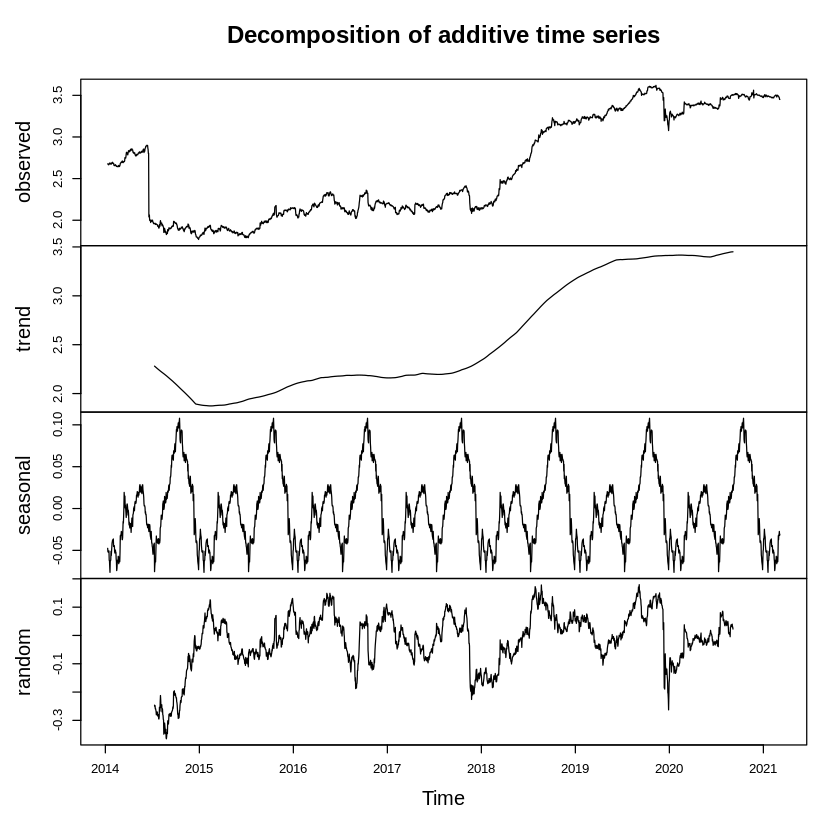

In [ ]:
# Decompose the time series data
decomposed_adani <- decompose(adani_ts)

# Plot the decomposed components
plot(decomposed_adani)

# Extract and view the components
trend_component <- decomposed_adani$trend
seasonal_component <- decomposed_adani$seasonal
irregular_component <- decomposed_adani$random




**Trend**

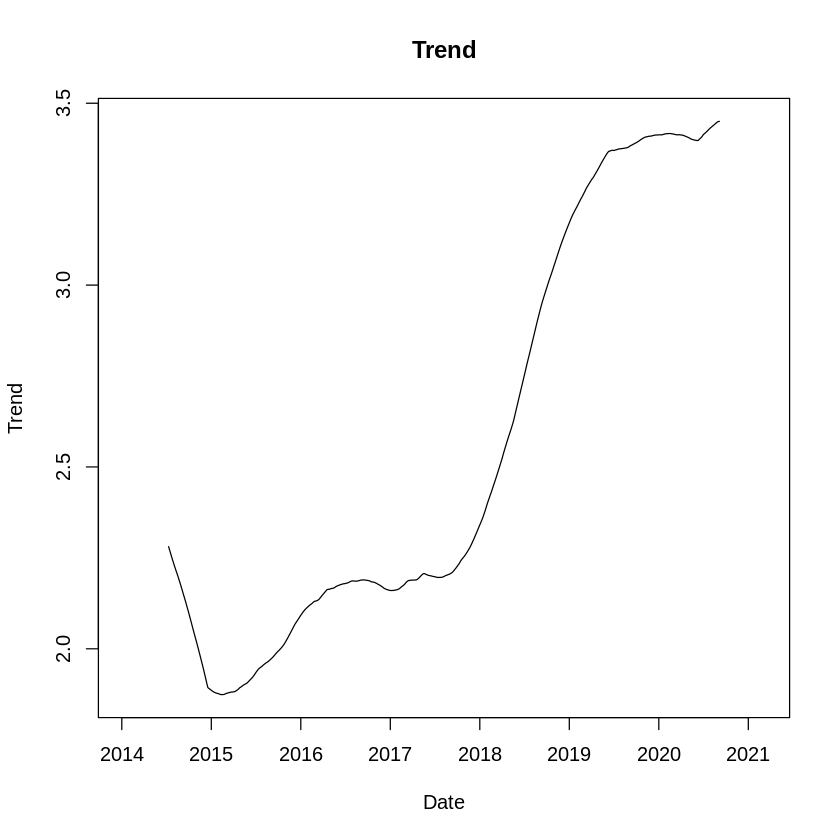

In [ ]:
plot(decomposed_adani$trend,main="Trend",xlab="Date",ylab="Trend")

The sudden raise from 2018 was because of the following reasons:

*   They started focusing on data centers , airports,renewable energy.
*   Benefits from government polices


*   Focused on renewable energy which  led to increased investments in solar and wind energy( Adani Green Energy)





**Plot with trend line**

`geom_smooth()` using formula = 'y ~ x'


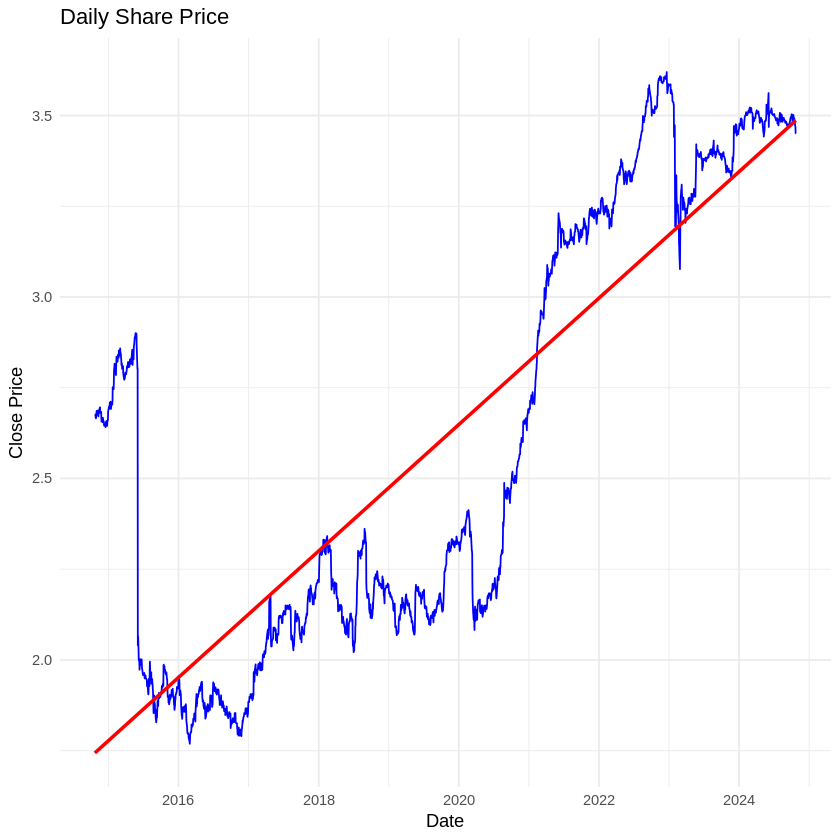

In [ ]:
#Plotting along with trend line
ggplot(adani_prices, aes(x=Date_N, y=logValue_N)) +
  geom_line(color="blue") +
  geom_smooth(method="lm", color="red", se=FALSE) +
  labs(title="Daily Share Price ", x="Date", y="Close Price") +
  theme_minimal()

**Trend Equation**

In [ ]:
# Fit the linear model
trend_model <- lm(logValue_N ~ Date_N, data = adani_prices)

# Get the summary of the model
model_summary <- summary(trend_model)

# Print the summary
print(model_summary)


Call:
lm(formula = logValue_N ~ Date_N, data = adani_prices)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.60505 -0.24534 -0.04076  0.14915  1.05540 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -6.060e+00  1.161e-01  -52.21   <2e-16 ***
Date_N       4.769e-04  6.369e-06   74.87   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.3434 on 2609 degrees of freedom
Multiple R-squared:  0.6824,	Adjusted R-squared:  0.6823 
F-statistic:  5605 on 1 and 2609 DF,  p-value: < 2.2e-16



So, the trend equation becomes:

logValue_N
=
−
6.060
+
0.0004769
×
Date_N
<br>
This means that over time, the log-transformed value of Adani prices has been increasing at a steady rate. The trend line shows that with each passing day (Date_N), the log value of Adani prices increases by approximately 0.0004769.


**Seasonality**



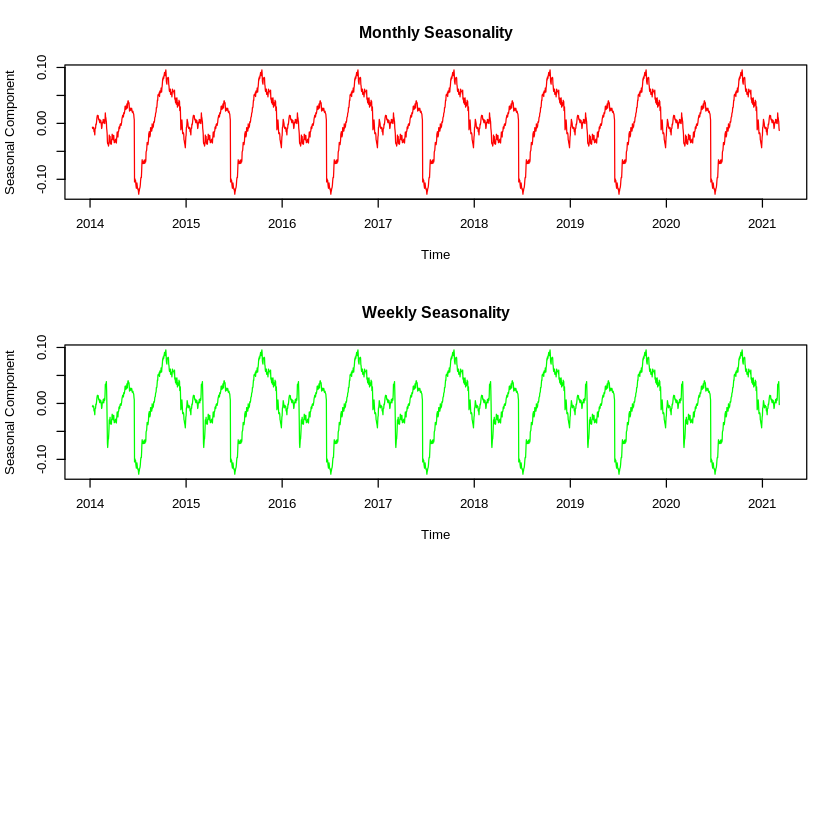

In [ ]:


# Decompose the time series for monthly seasonality
decomp_monthly <- stl(adani_ts, s.window="periodic", t.window=30)
monthly_seasonality <- decomp_monthly$time.series[, "seasonal"]

# Decompose the time series for weekly seasonality
decomp_weekly <- stl(adani_ts, s.window="periodic", t.window=7)
weekly_seasonality <- decomp_weekly$time.series[, "seasonal"]

# Plot the seasonality components
par(mfrow=c(3,1))


plot(monthly_seasonality, type="l", col="red", main="Monthly Seasonality", ylab="Seasonal Component", xlab="Time")
plot(weekly_seasonality, type="l", col="green", main="Weekly Seasonality", ylab="Seasonal Component", xlab="Time")

# Reset plotting layout
par(mfrow=c(1,1))

Checking for seasonality based on Kruskal-Wallis Test

In [ ]:
kw_test <- kw(adani_ts)
print(kw_test)

Test used:  Kruskall Wallis 
 
Test statistic:  421.41 
P-value:  0.0202067


Since the p-value is less than the common significance level of 0.05, you can reject the null hypothesis. This means that there is a statistically significant difference between the groups, suggesting that seasonality is present in our data.

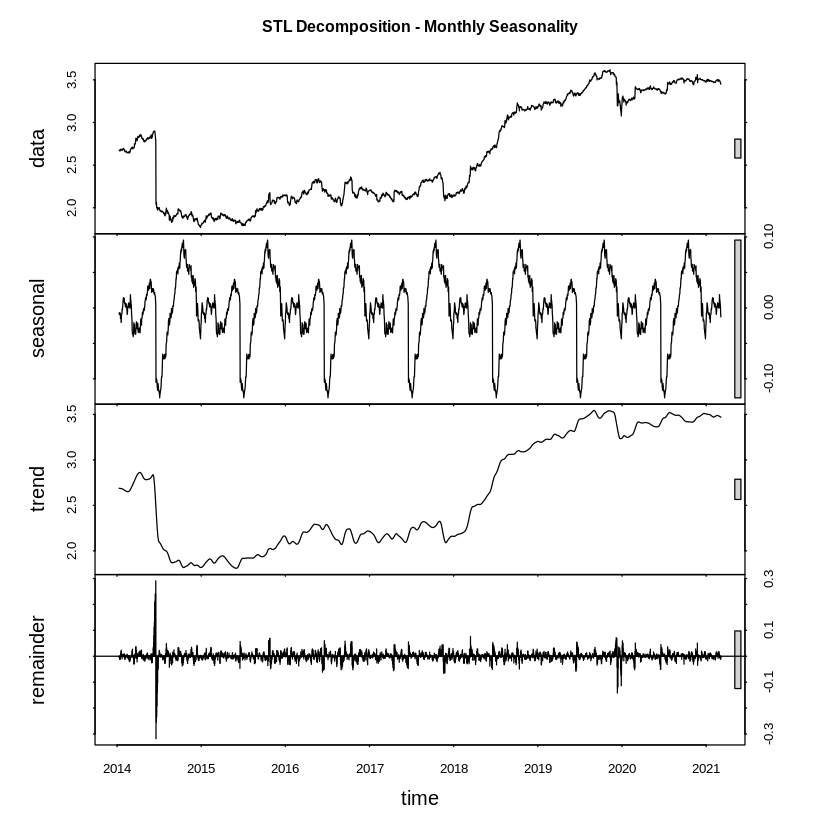

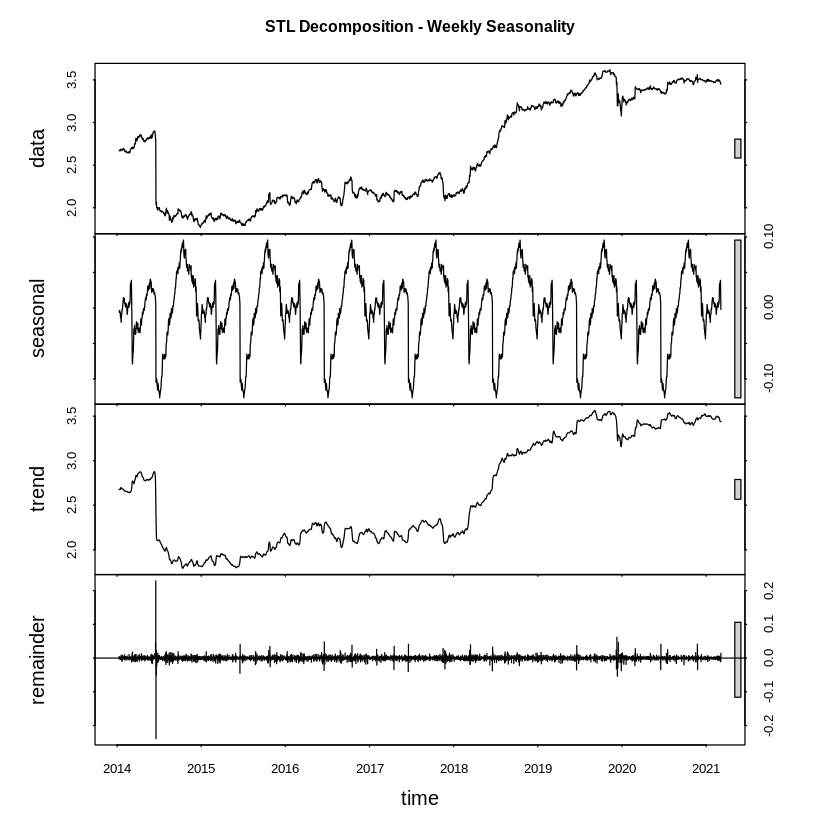

In [ ]:
# STL Decomposition with different seasonal windows
decomposed_monthly <- stl(adani_ts, s.window="periodic", t.window=30)
decomposed_weekly <- stl(adani_ts, s.window="periodic", t.window=7)

# Plot the decompositions
par(mfrow=c(3,1))
plot(decomposed_monthly, main="STL Decomposition - Monthly Seasonality")
plot(decomposed_weekly, main="STL Decomposition - Weekly Seasonality")
par(mfrow=c(1,1))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



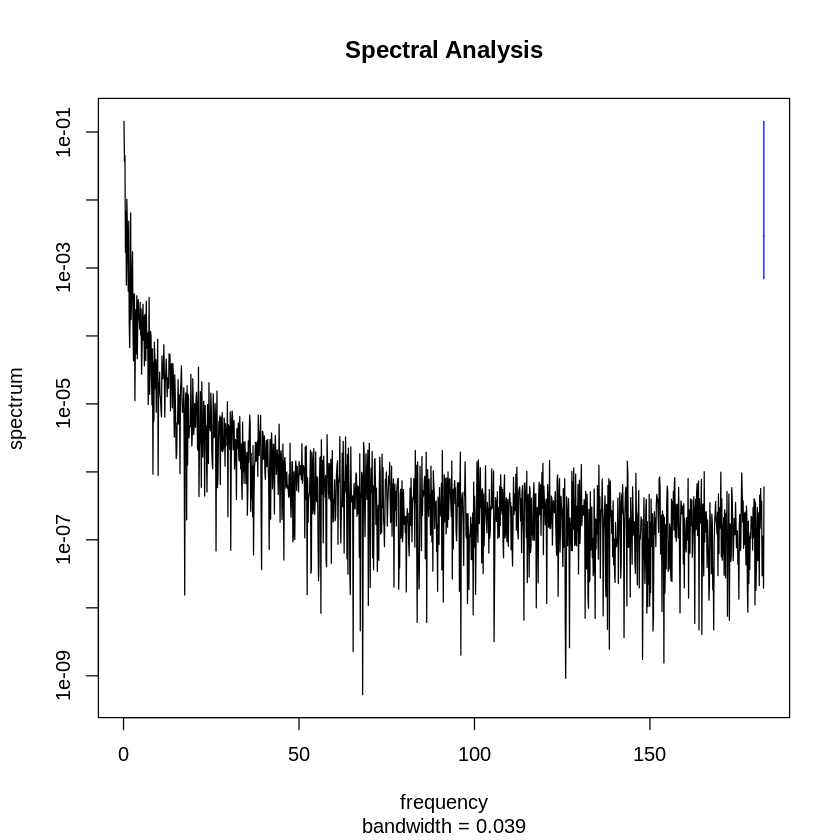

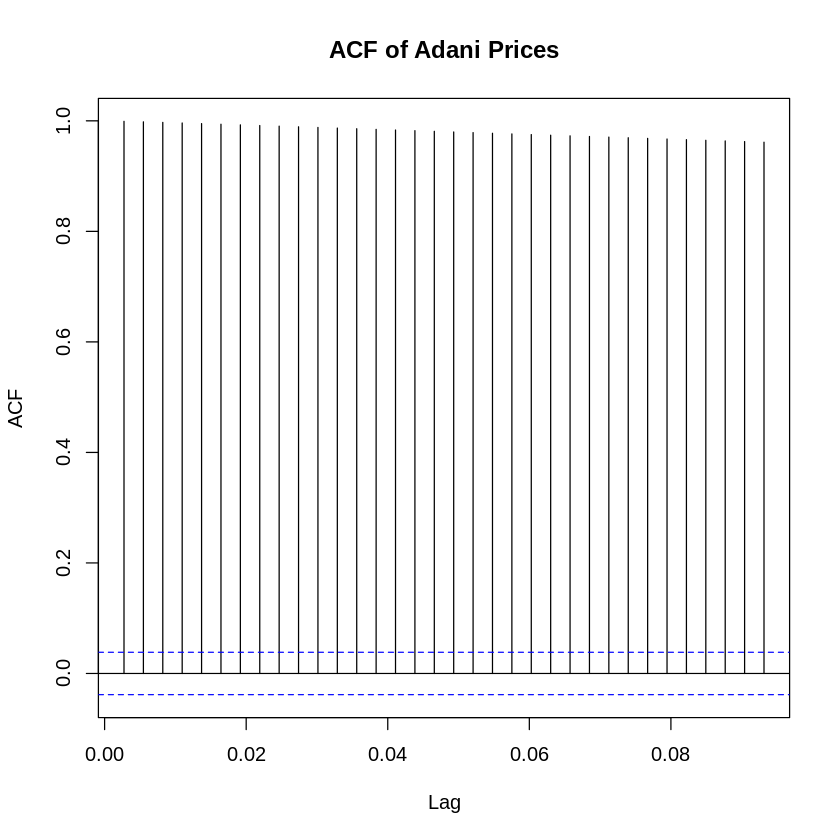

In [ ]:
# Load necessary libraries
library(forecast)
install.packages("TSA")
library(TSA)

# Periodogram
spectrum(adani_ts, main="Spectral Analysis")

# ACF plot
acf(adani_ts, main="ACF of Adani Prices")

Spectral Analysis Plot:

This shows how different frequencies contribute to the variance in your data. Peaks in this plot indicate dominant cycles. It doesn’t show any strong peaks, suggesting there might not be a clear periodicity detected by the spectral analysis.

ACF Plot:

The Auto-Correlation Function (ACF) plot indicates how the time series values at different lags are correlated. The quick drop-off to near zero suggests that there isn't a strong long-term autocorrelation pattern. This can imply that any seasonality present is subtle or not easily detectable through autocorrelation.

Given these results, it seems the seasonal patterns in your data might not be straightforward or very strong.

In [ ]:
# Assuming 'month' variable created from the Date
adani_prices$Month <- as.factor(format(adani_prices$Date_N, "%m"))
model <- lm(logValue_N ~ Month, data = adani_prices)
summary(model)



Call:
lm(formula = logValue_N ~ Month, data = adani_prices)

Residuals:
    Min      1Q  Median      3Q     Max 
-0.8530 -0.5088 -0.2785  0.6353  1.0227 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept)  2.628765   0.041051  64.036   <2e-16 ***
Month02     -0.006760   0.059405  -0.114    0.909    
Month03     -0.012039   0.057925  -0.208    0.835    
Month04      0.015457   0.058598   0.264    0.792    
Month05      0.013708   0.057990   0.236    0.813    
Month06     -0.037016   0.058459  -0.633    0.527    
Month07     -0.042673   0.058121  -0.734    0.463    
Month08     -0.005092   0.057925  -0.088    0.930    
Month09     -0.003967   0.058528  -0.068    0.946    
Month10     -0.020492   0.057990  -0.353    0.724    
Month11     -0.043151   0.058459  -0.738    0.460    
Month12     -0.022999   0.058055  -0.396    0.692    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.6103 on 2599 degrees of freedom
M

Results indicate that none of the monthly indicators (dummy variables for each month) are statistically significant. This suggests that there’s no strong monthly seasonal pattern in your data, given:

High p-values for each month: All are much greater than 0.05, indicating no significant monthly effect.

Low R-squared value: 0.0009844 implies that the month variables explain very little of the variance.

F-statistic p-value: 0.9953 shows the overall model isn't statistically significant.

Given these results, it's fair to conclude that there is no significant monthly seasonality in your data.

In [ ]:
library(seastests)

# Check for seasonality
seasonality_test <- isSeasonal(adani_ts)
print(seasonality_test)


[1] FALSE


It means that this specific test didn't find strong evidence of seasonality in your data.

**Cyclical variation**

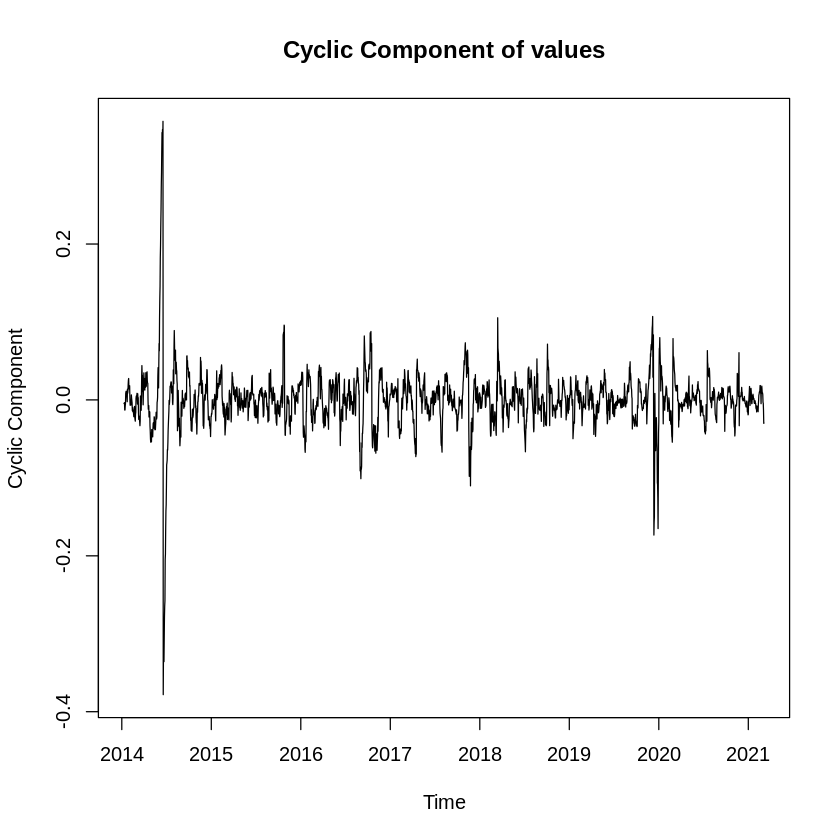

In [ ]:
# Extract the cyclic component using HP filter
hp_filter <- hpfilter(adani_ts, freq = 14400) #monthly
cyclic_component <- hp_filter$cycle

# Plot the cyclic component
plot(cyclic_component, type = "l", main = "Cyclic Component of values", xlab = "Time", ylab = "Cyclic Component")

stable period(2014-2019)
<br> increased volatality (2019-2021)- golbal events ,macroeconomic changes
<br> large spikes(2021 onwards) - policy changes

**Checking stationarity**

In [ ]:
result <- adf.test(adani_prices$Value_N)
print(result)
if (result$p.value < 0.05) {
    cat("values is likely stationary based on ADF test.\n")
  } else {
    cat("values is likely non-stationary based on ADF test.\n")
  }


	Augmented Dickey-Fuller Test

data:  adani_prices$Value_N
Dickey-Fuller = -2.4364, Lag order = 13, p-value = 0.3936
alternative hypothesis: stationary

values is likely non-stationary based on ADF test.


**REMOVING TREND**

Since our data is non stationary, we need to make it stationary before applying the AR,MA,ARMA models.


This is typically done through differencing. Differencing involves subtracting each data point from the previous one to remove trends and make the series stationary

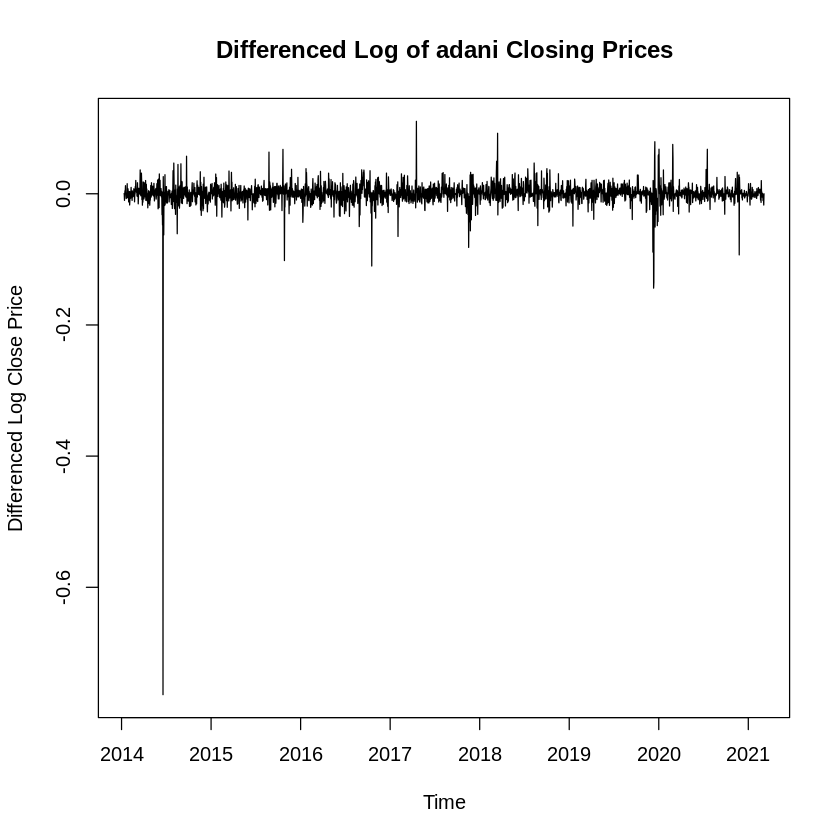

In [ ]:
# Perform differencing to make the series stationary
adani_diff <- diff(adani_ts, differences = 1)

# Plot the differenced series
plot(adani_diff, main="Differenced Log of adani Closing Prices", ylab="Differenced Log Close Price", xlab="Time")



Now we remove both trend and seasonality from the data

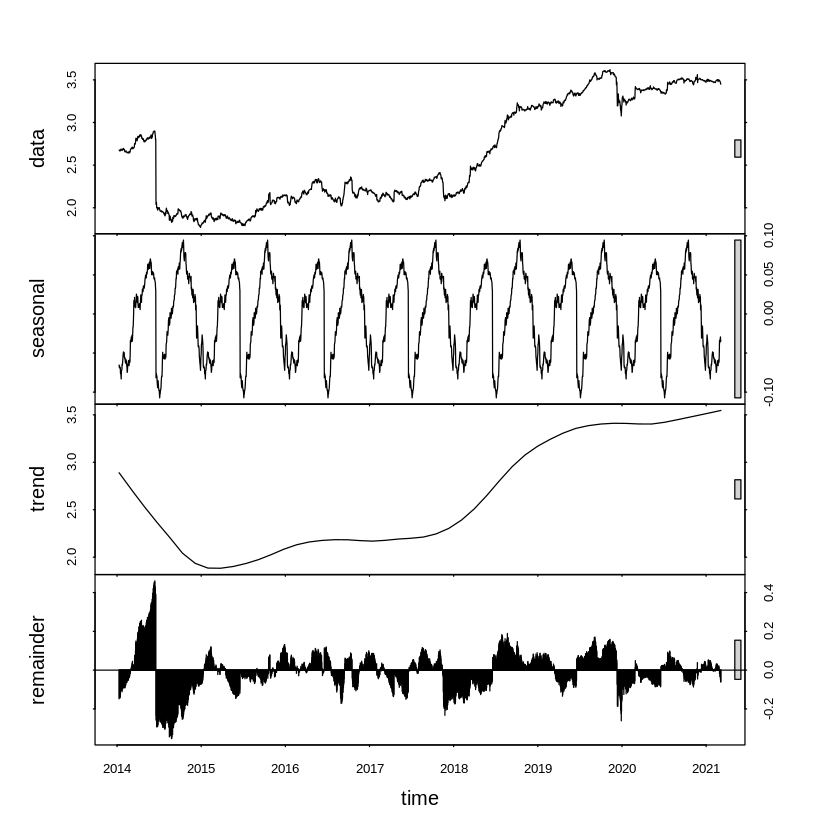

In [ ]:
# Decompose the time series
decomposed <- stl(adani_ts, s.window = "periodic")

# Plot the decomposed components
plot(decomposed)


In [ ]:
# Extract the components
trend <- decomposed$time.series[, "trend"]
seasonal <- decomposed$time.series[, "seasonal"]
remainder <- decomposed$time.series[, "remainder"]


# Remove the components
detrended_data <- adani_ts - trend
deseasonalized_data <- decomposed$time.series[, "remainder"]


In [ ]:
result <- adf.test(adani_diff)
print(result)
if (result$p.value < 0.05) {
    cat("values are likely stationary based on ADF test.\n")
  } else {
    cat("values are likely non-stationary based on ADF test.\n")
  }

Warning message in adf.test(adani_diff):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  adani_diff
Dickey-Fuller = -13.292, Lag order = 13, p-value = 0.01
alternative hypothesis: stationary

values are likely stationary based on ADF test.


**ACF and PACF**

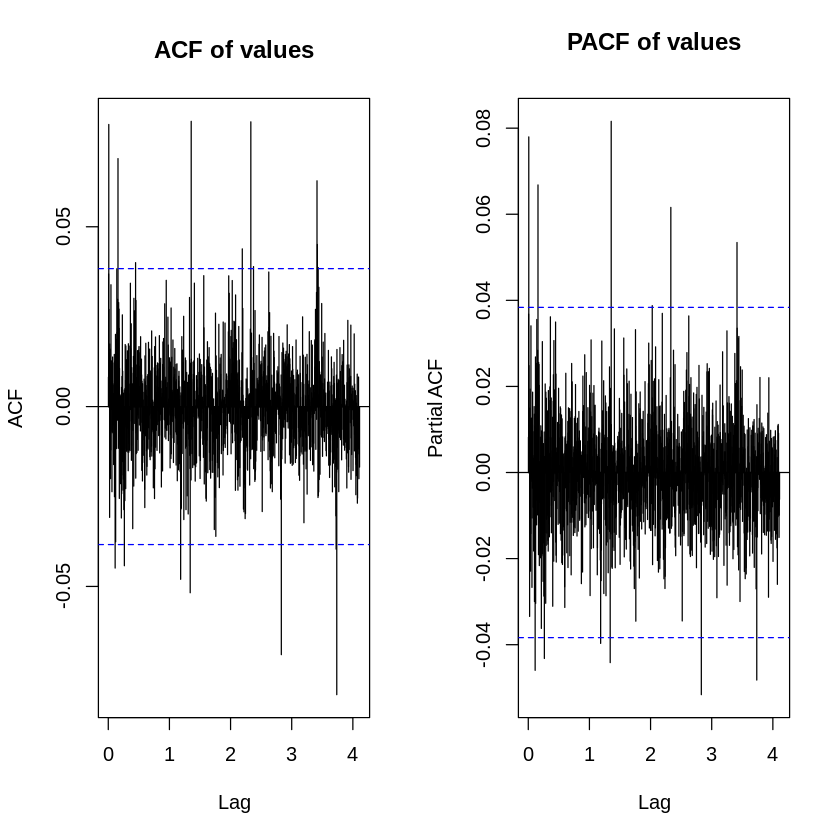

In [ ]:
# Plot ACF and PACF
par(mfrow = c(1, 2))

acf(adani_diff , lag.max=1500,main = "ACF of values")  # ACF plot
pacf(adani_diff ,lag.max=1500, main = "PACF of values")  # PACF plot

ACF Plot (left):
The ACF cuts off sharply after lag 1 and remains close to zero for higher lags.

This suggests a strong moving average (MA) component of order 1 (q=1).

PACF Plot (right):
The PACF cuts off sharply after lag 1 and remains close to zero for higher lags.

This suggests a strong autoregressive (AR) component of order 1 (p=1).

In [ ]:

# Fit AR(1) model
ar_model <- arima(adani_diff , order = c(1, 0, 0))
summary(ar_model)

Warning message in trainingaccuracy(object, test, d, D):
“test elements must be within sample”



Call:
arima(x = adani_diff, order = c(1, 0, 0))

Coefficients:
         ar1  intercept
      0.0082      3e-04
s.e.  0.0196      4e-04

sigma^2 estimated as 0.0004166:  log likelihood = 6453.74,  aic = -12903.47

Training set error measures:
              ME RMSE MAE MPE MAPE
Training set NaN  NaN NaN NaN  NaN

In [ ]:
# Fit MA(1) model
ma_model <- arima(adani_diff , order = c(0, 0, 1))
summary(ma_model)

Warning message in trainingaccuracy(object, test, d, D):
“test elements must be within sample”



Call:
arima(x = adani_diff, order = c(0, 0, 1))

Coefficients:
         ma1  intercept
      0.0076      3e-04
s.e.  0.0189      4e-04

sigma^2 estimated as 0.0004167:  log likelihood = 6453.73,  aic = -12903.46

Training set error measures:
              ME RMSE MAE MPE MAPE
Training set NaN  NaN NaN NaN  NaN

In [ ]:
# Fit ARMA(1,1) model
arma_model <- arima(adani_diff , order = c(1, 0, 1))
summary(arma_model)



Warning message in sqrt(diag(x$var.coef)):
“NaNs produced”
Warning message in trainingaccuracy(object, test, d, D):
“test elements must be within sample”



Call:
arima(x = adani_diff, order = c(1, 0, 1))

Coefficients:
         ar1     ma1  intercept
      0.0045  0.0034      3e-04
s.e.     NaN     NaN      4e-04

sigma^2 estimated as 0.0004166:  log likelihood = 6453.73,  aic = -12901.46

Training set error measures:
              ME RMSE MAE MPE MAPE
Training set NaN  NaN NaN NaN  NaN

In [ ]:
# Fit the ARIMA model
arima_model=auto.arima(adani_ts,d=0)
# Print the model summary
summary(arima_model)

Series: adani_ts 
ARIMA(0,0,5) with non-zero mean 

Coefficients:
         ma1     ma2     ma3     ma4     ma5    mean
      2.3217  3.1844  2.9457  1.8024  0.6047  2.6159
s.e.  0.0188  0.0355  0.0371  0.0249  0.0124  0.0154

sigma^2 = 0.004432:  log likelihood = 3368.89
AIC=-6723.79   AICc=-6723.74   BIC=-6682.71

Training set error measures:
                        ME       RMSE        MAE       MPE    MAPE      MASE
Training set -5.928157e-06 0.06649335 0.05173604 -0.462627 2.06416 0.1512137
                  ACF1
Training set 0.3476095

In [ ]:
# Extract AIC values
aic_values <- c(
    AR = AIC(ar_model),
    MA = AIC(ma_model),
     ARMA = AIC(arma_model),
    ARIMA = AIC(arima_model))
    # Print AIC values
print(aic_values)
# Identify the best model
best_model <- names(which.min(aic_values))
cat("The best model based on AIC is:", best_model, "\n")

        AR         MA       ARMA      ARIMA 
-12901.470 -12901.458 -12899.465  -6723.785 
The best model based on AIC is: AR 


In [ ]:
calculate_rmse <- function(model) {
  sqrt(mean(residuals(model)^2))
}


# RMSE for AR model
rmse_ar <- calculate_rmse(ar_model)

# RMSE for MA model
rmse_ma <- calculate_rmse(ma_model)

# RMSE for ARMA model
rmse_arma <- calculate_rmse(arma_model)

# RMSE for ARIMA model
rmse_arima <- calculate_rmse(arima_model)

# Extract rmse values
rmse_values <- c(
    AR = rmse_ar,
    MA = rmse_ma,
    ARMA = rmse_arma,
    ARIMA = rmse_arima
)

# Print rmse values
print(rmse_values)
# Identify the best model
best_model <- names(which.min(rmse_values))
cat("The best model based on RMSE is:", best_model, "\n")

        AR         MA       ARMA      ARIMA 
0.02041197 0.02041201 0.02041199 0.06649335 
The best model based on RMSE is: AR 
